# Hybrid Quantum-Classical VQE for Molecule Energy Estimation

## Variational Quantum Eigensolver (VQE) for $H_2$ Molecule

## 1. Problem Statement

The goal of this project is to implement a Variational Quantum Eigensolver (VQE) to estimate the ground state energy of the hydrogen molecule (H₂). The implementation combines a quantum circuit that prepares trial molecular states and a classical optimizer that updates circuit parameters iteratively to minimize the measured energy.

The project demonstrates the concept of hybrid quantum-classical computing where:

- the quantum component evaluates molecular energy expectation values
- the classical optimizer improves variational parameters
- repeated iterations gradually approach the molecular ground state energy

The hydrogen molecule is chosen because it is one of the simplest molecular systems and is widely used as a benchmark problem in quantum chemistry simulations.

### Objectives of the Project

- Define the H₂ molecular system
- Construct the molecular Hamiltonian
- Map the Hamiltonian into qubit operators
- Design a variational ansatz circuit
- Optimize variational parameters using a classical optimizer
- Analyze convergence behavior
- Compare VQE results with exact classical solutions

<p align="center">
    <img src="../images/A-Hybrid-Quantum-Classical-Optimization-Workflow-adapted-from-115-The-diagram.jpg" width="65%" />
    <figcaption align="center"><b>Figure 1:</b> Hybrid workflow of the Variational Quantum Eigensolver algorithm.</figcaption>
</p>

## 2. Conceptual Understanding

### 2.1 Quantum States and Qubits

Qubits are the fundamental units of quantum computation. Unlike classical bits, qubits can exist in superposition states and are capable of representing molecular quantum states efficiently.

In molecular simulations, qubits are used to encode electronic configurations of molecules.

### 2.2 Hamiltonian

The Hamiltonian is the operator representing the total energy of the molecular system. It includes:

- electron-electron interactions
- electron-nucleus interactions
- kinetic energy contributions
- nuclear repulsion energy

The VQE algorithm minimizes the expectation value of the Hamiltonian to estimate the molecular ground state energy.

### 2.3 Molecular Ground State Energy

The molecular ground state energy is the lowest possible energy that the molecule can possess.

Estimating this value accurately is one of the primary goals of quantum chemistry.

### 2.4 Quantum Circuits

Parameterized quantum circuits are used to prepare trial wavefunctions for the molecule.

The parameters of the circuit are updated iteratively during optimization.

### 2.5 Hybrid Quantum-Classical Optimization

The VQE algorithm operates using a feedback loop:

1. The quantum circuit prepares a molecular trial state.
1. The quantum computer estimates the energy expectation value.
1. A classical optimizer updates the circuit parameters.
1. The process repeats until convergence.

### 2.6 Quantum Measurement

The quantum circuit measurements are used to estimate expectation values of Pauli operators present in the qubit Hamiltonian.

### 2.7 Qubit Mapping Techniques

Electronic molecular operators must be transformed into qubit operators before quantum execution.

This project uses the Jordan-Wigner mapping technique.

<p align="center">
    <img src="../images/ariational-Quantum-Eigensolver-VQE-algorithm-flowchart_W640.jpg" width="35%" />
    <figcaption align="center"><b>Figure 2:</b> Conceptual workflow of the Variational Quantum Eigensolver algorithm.</figcaption>
</p>

## 3. Import Required Libraries

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit.circuit.library import TwoLocal
from qiskit.primitives import StatevectorEstimator

from qiskit_algorithms.minimum_eigensolvers import (
    VQE,
    NumPyMinimumEigensolver,
)

from qiskit_algorithms.optimizers import COBYLA

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.mappers import JordanWignerMapper

## 4. Define the Molecule

The hydrogen molecule (H₂) is one of the simplest molecular systems and is commonly used as a benchmark for quantum chemistry algorithms.

The molecular geometry used in this project is:

$$
H - H = 0.735 \text{ \AA}
$$

The STO-3G basis set is used because it provides a computationally efficient minimal basis suitable for introductory VQE studies.

<p align="center">
    <img src="../images/hydrogen-molecule-atomic-structure-simplified-chemistry-icse-class-9-847x380.jpg" width="45%" />
    <img src="../images/hydrogenorbitals.jpg" width="45%" />
    <figcaption align="center"><b>Figure 3 & 4:</b> Geometry and electronic structure of the hydrogen molecule.</figcaption>
</p>

In [16]:
# Define H2 molecule

driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",
    basis="sto3g",
    unit=DistanceUnit.ANGSTROM,
)

problem = driver.run()

## 5. Convert the Hamiltonian into Qubit Form

The electronic structure Hamiltonian generated from quantum chemistry must be mapped into qubit operators before execution on a quantum computer.

In this project, the Jordan-Wigner transformation is used.

### Jordan-Wigner Mapping

The Jordan-Wigner mapping transforms fermionic creation and annihilation operators into Pauli operators acting on qubits.

Advantages:

- Simple and intuitive mapping
- Widely used in introductory VQE studies
- Easy interpretation of qubit operators

<p align="center">
    <img src="../images/jw_mapping.jpg" width="45%" />
    <figcaption align="center"><b>Figure 5:</b> Mapping fermionic operators into qubit operators using Jordan-Wigner encoding.</figcaption>
</p>

### Hamiltonian Mapping Code

In [17]:
# Generate second-quantized operators
second_q_ops = problem.second_q_ops()
hamiltonian = second_q_ops[0]

# Apply Jordan-Wigner mapping
mapper = JordanWignerMapper()
qubit_op = mapper.map(hamiltonian)

print(qubit_op)

SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IIZZ', 'IZII', 'IZIZ', 'ZIII', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.81054798+0.j,  0.17218393+0.j, -0.22575349+0.j,  0.12091263+0.j,
  0.17218393+0.j,  0.16892754+0.j, -0.22575349+0.j,  0.16614543+0.j,
  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,
  0.16614543+0.j,  0.17464343+0.j,  0.12091263+0.j])


## 6. Exact Classical Ground State Solution

Before executing the VQE algorithm, the exact ground state energy is computed using classical exact diagonalization.

This acts as the reference value for evaluating VQE performance.

### Exact Solver

In [18]:
solver = NumPyMinimumEigensolver()

exact_result = solver.compute_minimum_eigenvalue(qubit_op)

exact_electronic_energy = exact_result.eigenvalue.real

nuclear_repulsion_energy = problem.nuclear_repulsion_energy

exact_total_energy = (
    exact_electronic_energy
    + nuclear_repulsion_energy
)

print("Exact Electronic Energy:", exact_electronic_energy)
print("Exact Total Energy:", exact_total_energy)

Exact Electronic Energy: -1.857275030202382
Exact Total Energy: -1.1373060357534022


## 7. Create a Quantum Circuit (Ansatz)

The ansatz is the parameterized quantum circuit used to approximate the molecular wavefunction.

For the main implementation, a hardware-efficient TwoLocal ansatz is used.

## _Why This Ansatz Was Chosen_

The implementation uses a compact hardware-efficient ansatz with:

- RY and RZ rotation gates
- Linear entanglement
- CX entangling gates
- Single repetition layer

This design was selected because:

- It produces stable convergence
- It avoids unnecessarily deep circuits
- It is easy to interpret visually
- It demonstrates hybrid optimization effectively
- It balances simplicity and performance
- It improves variational expressibility without significantly increasing circuit complexity

The ansatz combines RY and RZ rotational layers together with linear CX entanglement. The inclusion of both rotational axes improves the circuit's ability to represent molecular quantum states while still maintaining a shallow and hardware-efficient structure suitable for NISQ-era quantum computation.

- It improves expressibility while maintaining low circuit depth

The ansatz uses both RY and RZ rotation gates together with linear CX entanglement. This provides improved variational flexibility compared to using only a single rotation axis, while still maintaining a shallow and hardware-efficient circuit structure suitable for NISQ-era quantum devices.

### Ansatz Design

In [19]:
num_qubits = qubit_op.num_qubits

ansatz = TwoLocal(
    num_qubits,
    rotation_blocks=["ry", "rz"],
    entanglement_blocks="cx",
    entanglement="linear",
    reps=1,
    insert_barriers=True,
)

/tmp/ipykernel_890/1680852385.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(


### Visualizing the Ansatz

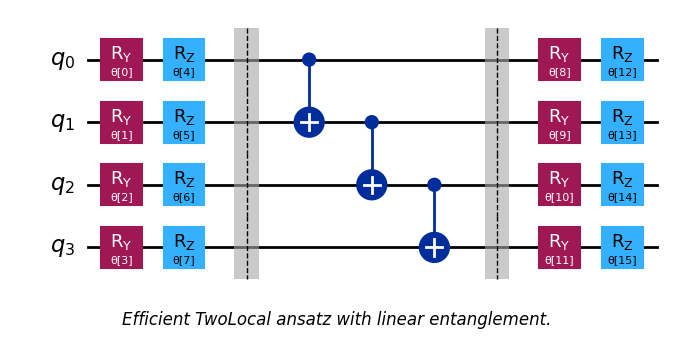

In [20]:
ansatz_decomposed = ansatz.decompose()

fig = ansatz_decomposed.draw("mpl")

# Add the caption as a centered title at the bottom of the figure
fig.suptitle("Efficient TwoLocal ansatz with linear entanglement.", 
             fontsize=12, y=0.05, style='italic')

# Adjust layout to ensure the caption doesn't overlap the circuit
fig.tight_layout(rect=[0, 0.08, 1, 1])

fig

## 8. Choose a Classical Optimizer

The classical optimizer updates the ansatz parameters iteratively to minimize the expectation value of the Hamiltonian.

In this implementation, COBYLA is used.

### Why COBYLA?

COBYLA is a derivative-free optimization algorithm used to iteratively optimize the variational circuit parameters.

The optimizer works efficiently for shallow variational quantum circuits and is widely used in VQE implementations for small molecular systems.

Advantages:

- Stable convergence for small VQE systems
- Does not require analytical gradients
- Works effectively with variational quantum circuits

<p align="center">
    <img src="../images/Classical Optimizer Feedback Loop.jpg" width="49%" />
    <img src="../images/energy minimization landscape.jpg" width="49%" />
    <figcaption align="center"><b>Figure 6 & 7:</b> Classical optimization process in the VQE algorithm.</figcaption>
</p>

### Optimizer Definition

In [21]:
optimizer = COBYLA(maxiter=300)

## 9. Iterative Hybrid Quantum-Classical Optimization

The VQE algorithm evaluates the expectation value of the Hamiltonian using the parameterized ansatz circuit.

The optimizer updates circuit parameters iteratively until convergence.

### VQE Execution

In [22]:
energy_history = []


def callback(eval_count, params, mean, std):
    energy_history.append(mean)


estimator = StatevectorEstimator()

vqe = VQE(
    estimator,
    ansatz,
    optimizer,
    callback=callback,
)

The callback function stores the energy values obtained during every optimization iteration. These values are later used to generate the convergence plot.

### Final Energy Calculation

In [23]:
# Single VQE execution
result = vqe.compute_minimum_eigenvalue(qubit_op)

vqe_electronic_energy = result.eigenvalue.real

vqe_total_energy = (
    vqe_electronic_energy
    + nuclear_repulsion_energy
)

print("VQE Electronic Energy:", vqe_electronic_energy)
print("VQE Total Energy:", vqe_total_energy)

VQE Electronic Energy: -1.8374482505695364
VQE Total Energy: -1.1174792561205567


## 10. Error Analysis

The VQE result is compared with the exact classical solution.

The total energy error is calculated as:

$$
\text{Error} = |E_{VQE} - E_{Exact}|
$$

### Error Computation

In [24]:
energy_error = abs(
    vqe_total_energy
    - exact_total_energy
)

print("Total Energy Error:", energy_error)

Total Energy Error: 0.019826779632845515


## 11. Runtime Analysis

Runtime analysis helps compare computational efficiency between different VQE models and optimizers.

The runtime measures:

- ansatz evaluations
- optimizer iterations
- estimator computations

### Runtime Measurement

In [25]:
import time

energy_history = []


def callback(eval_count, params, mean, std):
    energy_history.append(mean)


estimator = StatevectorEstimator()

vqe = VQE(
    estimator,
    ansatz,
    optimizer,
    callback=callback,
)

# Start runtime measurement
start_time = time.time()

# Execute VQE ONLY ONCE
result = vqe.compute_minimum_eigenvalue(qubit_op)

# End runtime measurement
end_time = time.time()

runtime = end_time - start_time

print(f"Runtime: {runtime:.4f} seconds")

Runtime: 1.3565 seconds


The runtime measurement is performed around the single VQE execution step. This avoids duplicate optimizer executions and prevents duplicated convergence histories in the energy convergence plot.

## 12. Plot Energy Convergence

The convergence plot shows how the energy estimate improves during optimization.

A stable convergence curve indicates:

- efficient optimization
- good ansatz design
- stable parameter updates
- effective entanglement structure

### Plotting the Convergence Curve

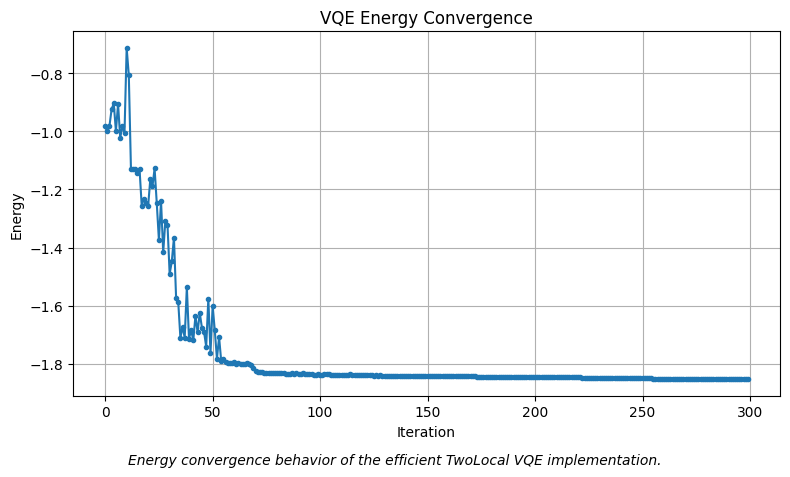

In [26]:
# Ensure clean plotting state
plt.clf()
plt.close('all')

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    energy_history,
    marker='o',
    markersize=3,
    linewidth=1.5,
)

ax.set_xlabel("Iteration")
ax.set_ylabel("Energy")
ax.set_title("VQE Energy Convergence")
ax.grid(True)

# --- ADDED CAPTION LOGIC ---
# fig.text parameters: x, y, string, horizontalalignment, style
fig.text(0.5, 0.01, "Energy convergence behavior of the efficient TwoLocal VQE implementation.", 
         ha='center', fontsize=10, style='italic')

# Adjust layout to prevent the caption from being cut off
fig.tight_layout(rect=[0, 0.03, 1, 0.95]) 
# ---------------------------

plt.show()
plt.close(fig)

## 13. Expected Results and Final Outputs

In [27]:
from IPython.display import display, HTML
import pandas as pd

results_table = pd.DataFrame({
    "Quantity": [
        "Exact Total Energy",
        "VQE Total Energy",
        "Total Energy Error",
        "Runtime (s)",
        "Optimizer",
        "Ansatz"
    ],
    "Value": [
        f"{exact_total_energy:.12f}",
        f"{vqe_total_energy:.12f}",
        f"{energy_error:.6e}",
        f"{runtime:.4f}",
        "COBYLA",
        "TwoLocal (RY-RZ + Linear CX)"
    ]
})

styled_table = (
    results_table.style
    .hide(axis="index")
    .set_properties(**{
        'text-align': 'center',
        'padding': '10px',
        'border': '1px solid gray'
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('text-align', 'center'),
                ('padding', '10px'),
                ('border', '1px solid gray')
            ]
        },
        {
            'selector': 'table',
            'props': [
                ('border-collapse', 'collapse'),
                ('font-size', '14px')
            ]
        }
    ])
)

display(HTML(
    f"""
    <div style="display: flex; justify-content: center; margin-top: 10px;">
        {styled_table.to_html()}
    </div>
    """
))

Quantity,Value
Exact Total Energy,-1.137306035753
VQE Total Energy,-1.117479256121
Total Energy Error,1.982678e-02
Runtime (s),1.3565
Optimizer,COBYLA
Ansatz,TwoLocal (RY-RZ + Linear CX)


## 14. Additional VQE Configurations Explored

In addition to the primary implementation, several alternative VQE configurations were explored to study how ansatz design, mapping methods, and optimizer selection affect convergence behavior, runtime, and final energy accuracy.

## Alternative Configuration 1 — Dense Hardware-Efficient Ansatz

### Features
- Full entanglement
- RY + RZ rotations
- Two repetition layers
- CZ entangling gates

### Observations
- More expressive ansatz
- Larger circuit depth
- Slower convergence
- Increased optimization complexity

<p align="center">
  <img src="../images/VQE_A_convergence_plot.png" width="30%" />
  <img src="../images/VQE_A_ansatz_circuit.png" width="70%" />
  <br>
  <small><b>Figure 8 & 9:</b> Convergence plot and circuit diagram for the hardware-efficient ansatz.</small>
</p>

### <u>**Discussion**</u>
This configuration used a deeper hardware-efficient ansatz with repeated RY-RZ rotational layers and dense entanglement connections between qubits.

The convergence plot showed faster initial energy reduction but also exhibited stronger oscillations during intermediate optimization stages before stabilizing near the final energy value.

The final VQE electronic energy obtained was:

$$
-1.8080514981619162
$$

with an energy error of approximately:

$$
0.0492
$$

The increased circuit expressibility improved variational flexibility but also increased optimization complexity and convergence instability.


## Alternative Configuration 2 — Chemistry-Inspired UCCSD Ansatz

### Features
- UCCSD ansatz
- Hartree-Fock initial state
- Chemistry-inspired wavefunction preparation
- L-BFGS-B optimizer

### Observations
- Most physically meaningful ansatz
- Improved final accuracy
- Higher circuit complexity
- Longer runtime

<p align="center">
  <img src="../images/VQE_C_convergence_plot.png" width="30%" />
  <img src="../images/VQE_C_ansatz_circuit.png" width="60%" />
  <br>
  <small><b>Figure 10 & 11:</b> Convergence plot and circuit diagram for the chemistry-inspired UCCSD ansatz.</small>
</p>

### <u>**Discussion**</u>

This configuration used a chemistry-inspired UCCSD ansatz for molecular state preparation. The convergence plot showed gradual stabilization toward the molecular ground state energy with improved final accuracy compared to hardware-efficient circuits.

The final VQE electronic energy obtained was:

$$
-1.8572750302018828
$$

with an energy error of approximately:

$$
4.96 \times 10^{-13}
$$

The runtime for this configuration was approximately:

$$
1.8285 \text{ seconds}
$$

The results showed that the UCCSD ansatz achieved highly accurate molecular energy estimation at the expense of increased circuit complexity and runtime.


## Alternative Configuration 3 — Optimizer Comparison Study

### Optimizers Compared
- COBYLA
- SPSA
- L-BFGS-B

### Objective
To analyze how classical optimization algorithms affect:

- convergence speed
- stability
- runtime
- final energy accuracy

<p align="center">
  <img src="../images/VQE_D_optimizer_comparison_plot.png" width="40%" />
  <img src="../images/VQE_D_ansatz_circuit.png" width="50%" />
  <br>
  <small><b>Figure 12 & 13:</b> Optimizer convergence comparison and variational ansatz structure.</small>
</p>

### <u>**Discussion**</u>

This configuration compared the performance of different classical optimizers using the same variational ansatz structure.

The convergence plot showed that:
*   **COBYLA** exhibited the smoothest and most stable convergence behavior.
*   **SPSA** showed significant oscillations and noisy parameter updates during optimization.
*   **L-BFGS-B** converged in a more abrupt step-like manner but achieved the most accurate final energy

The final electronic energy errors obtained were approximately:

$$
\text{COBYLA: } 2.03 \times 10^{-2}
$$

$$
\text{SPSA: } 6.94 \times 10^{-4}
$$

$$
\text{L-BFGS-B: } 6.30 \times 10^{-11}
$$

The results demonstrated that optimizer selection strongly influences convergence stability, runtime, and final energy accuracy in VQE implementations.


## 15. Comparative Analysis

This project successfully implemented the Variational Quantum Eigensolver algorithm for estimating the ground state energy of the hydrogen molecule.

The efficient hardware-efficient ansatz used in the main implementation provided:

- stable convergence
- low circuit depth
- good computational efficiency
- accurate energy estimation

The additional configurations explored in this project demonstrated that:

- ansatz design strongly affects convergence behavior
- optimizer choice influences runtime and stability
- chemistry-inspired ansätze improve physical accuracy
- shallow circuits often provide better optimization efficiency for small systems

The project demonstrates the effectiveness of hybrid quantum-classical algorithms for molecular energy estimation and highlights the importance of variational circuit design in quantum chemistry applications.

## 16. Final Conclusion

The Variational Quantum Eigensolver algorithm was successfully implemented for estimating the ground state energy of the hydrogen molecule.

The final implementation demonstrated:

- successful Hamiltonian construction
- efficient variational state preparation using a hardware-efficient TwoLocal ansatz with RY-RZ rotational layers
- iterative hybrid optimization
- stable energy convergence
- accurate estimation of molecular ground state energy

The convergence plots, runtime analysis, and error comparisons showed the effectiveness of hybrid quantum-classical computation for quantum chemistry problems.

The additional configurations further demonstrated how ansatz complexity and optimizer selection influence convergence behavior and computational performance.

## References

1. [Qiskit Documentation](https://qiskit.org/documentation/) - Official documentation for the Qiskit quantum computing framework.
1. [Qiskit Nature Documentation](https://qiskit-community.github.io/qiskit-nature/) - Documentation for molecular Hamiltonian generation and quantum chemistry workflows.
1. [Qiskit Algorithms Documentation](https://qiskit-community.github.io/qiskit-algorithms/) - Reference for VQE algorithms and classical optimizers.
1. [NumPy Documentation](https://numpy.org/doc/) - Numerical computing library used for calculations and parameter handling.
1. [Matplotlib Documentation](https://matplotlib.org/stable/users/index.html) - Visualization library used for convergence and energy plots.
1. [Qiskit Textbook – VQE Applications](https://github.com/Qiskit/textbook/tree/main/notebooks/ch-applications)
1. [PennyLane VQE Tutorial](https://pennylane.ai/qml/demos/tutorial_vqe/)
1. [IBM Quantum Learning – Variational Quantum Eigensolver](https://learning.quantum.ibm.com/tutorial/variational-quantum-eigensolver)
1. Peruzzo, A., et al., “A Variational Eigenvalue Solver on a Quantum Processor,” _Nature Communications_, 5, 4213 (2014). DOI: 10.1038/ncomms5213
1. Kandala, A., et al., “Hardware-efficient Variational Quantum Eigensolver for Small Molecules and Quantum Magnets,” _Nature_, 549, 242–246 (2017). DOI: 10.1038/nature23879